Deduplication proba

In [28]:
# Dates management
import datetime

import numpy as np

import matplotlib.pyplot as plt
# Visualization library
import altair as alt

# Data manipulation library
import pandas as pd

# Enable Altair to display all rows of data
alt.data_transformers.enable('default', max_rows=None)

DataTransformerRegistry.enable('default')

In [12]:
# Lecture du fichier proba
df_person = pd.read_pickle("datap/df_person_fix.pkl")

df_dedup_proba = pd.read_pickle("datap/df_dedup_proba.pkl")

print(df_dedup_proba.head())
df_dedup_proba['prob'].describe()


     unique_person_id   person_id      prob
100        81076351.0  81292219.0  1.000000
48         86827620.0  87604616.0  1.000000
109        88836037.0  86178595.0  0.754593
70         84763748.0  82185488.0  1.000000
45         81097903.0  80952185.0  1.000000


count    117.000000
mean       0.693285
std        0.322495
min        0.032158
25%        0.425910
50%        0.865630
75%        1.000000
max        1.000000
Name: prob, dtype: float64

<Axes: ylabel='Density'>

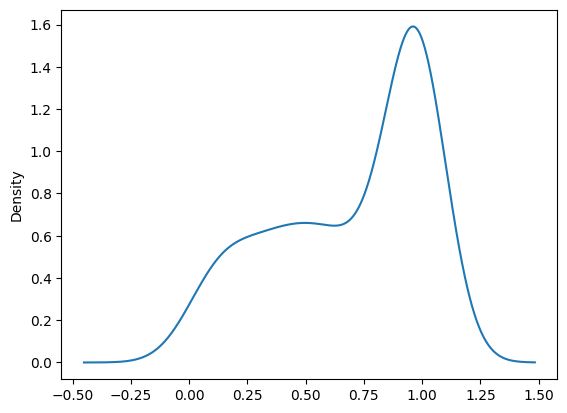

In [16]:
# Print de la densité:
df_dedup_proba['prob'].plot.density()

In [18]:
def deduplicate_proba(df_person: pd.DataFrame, df_dedup_proba: pd.DataFrame, score: int):
    #Only keep rows with a probability above the value score
    df_dedup_proba_score = df_dedup_proba[df_dedup_proba['prob'] > score]
    # Outer Join
    df_person_dedup_proba  = pd.merge(df_person, df_dedup_proba_score, on = 'person_id', how = 'outer')
    # Only unique ids in unique_person_id
    df_person_dedup_proba['unique_person_id'] = df_person_dedup_proba['unique_person_id'].fillna(df_person_dedup_proba['person_id'])
    # Only keep one row per patient
    df_person_dedup_proba = df_person_dedup_proba.drop_duplicates(['unique_person_id'], keep = 'first')
    return df_person_dedup_proba

In [19]:
df_person_dedup_proba_90 = deduplicate_proba(df_person, df_dedup_proba, score=0.90)
print(f"We have {df_person_dedup_proba_90.unique_person_id.nunique()} unique patient ids in this dataset when using the probabilistic algorithm and a threshold of 0.90.")

We have 1476 unique patient ids in this dataset when using the probabilistic algorithm and a threshold of 0.90.


In [20]:
df_person_dedup_proba_20 = deduplicate_proba(df_person, df_dedup_proba, score = 0.20)
print(f"We have {df_person_dedup_proba_20.unique_person_id.nunique()} unique patient ids in this dataset when using the probabilistic algorithm and a threshold of 0.20.")


We have 1426 unique patient ids in this dataset when using the probabilistic algorithm and a threshold of 0.20.


Text(0, 0.5, 'nombre de personnes restantes')

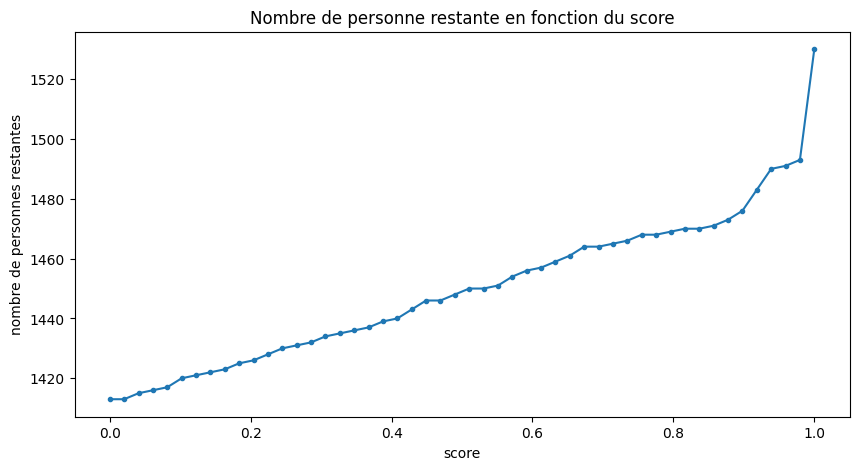

In [37]:
# df_person.head()
# print(len(df_person))

threshold = np.linspace(0, 1, num=50)
n_remaining = []

for t in threshold:
    dt = deduplicate_proba(df_person, df_dedup_proba, score = t)
    n_remaining.append(dt["unique_person_id"].nunique())
    
plt.figure(figsize=(10, 5))
plt.plot(thresholds, n_remaining, marker='o', markersize=3)
plt.title("Nombre de personne restante en fonction du score")
plt.xlabel("score")
plt.ylabel("nombre de personnes restantes")




Seuil optimal (elbow) : 0.980


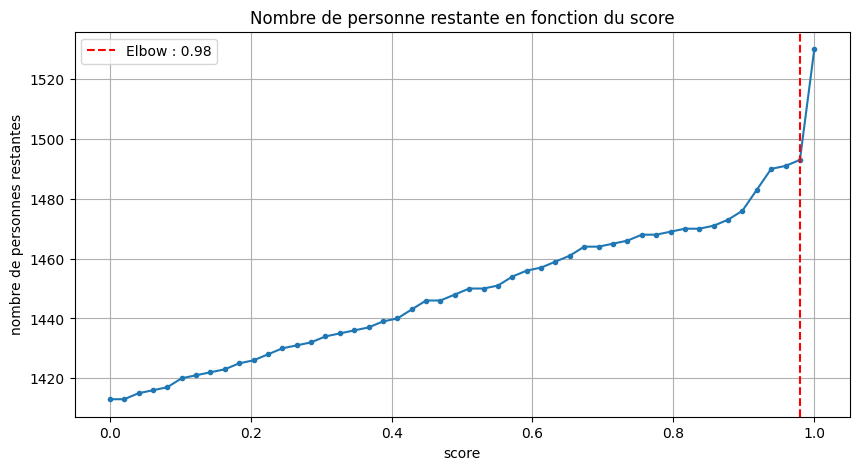

We have 1493 unique patient ids in this dataset when using the probabilistic algorithm and a the optimal threshold.


In [42]:

# Utilisation de la méthode du coude pour trouver le meilleur score

threshold = np.linspace(0, 1, num=50)
n_remaining = []

for t in threshold:
    dt = deduplicate_proba(df_person, df_dedup_proba, score=t)
    n_remaining.append(dt["unique_person_id"].nunique())

# --- Elbow (dérivée seconde) ---
n = np.array(n_remaining)
d2 = np.diff(np.diff(n))
elbow_idx = np.argmax(d2) + 1
optimal_threshold = threshold[elbow_idx]

print(f"Seuil optimal (elbow) : {optimal_threshold:.3f}")

# --- Plot ---
plt.figure(figsize=(10, 5))
plt.plot(threshold, n_remaining, marker='o', markersize=3)  # ✅ threshold partout
plt.axvline(x=optimal_threshold, color='red', linestyle='--',
            label=f"Elbow : {optimal_threshold:.2f}")
plt.title("Nombre de personne restante en fonction du score")
plt.xlabel("score")
plt.ylabel("nombre de personnes restantes")
plt.legend()
plt.grid(True)
plt.show()


df_person_dedup_proba_elbow = deduplicate_proba(df_person, df_dedup_proba, score = optimal_threshold)
print(f"We have {df_person_dedup_proba_elbow.unique_person_id.nunique()} unique patient ids in this dataset when using the probabilistic algorithm and a the optimal threshold.")
